# Imports

In [54]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [55]:
import matplotlib
from matplotlib.image import NonUniformImage

In [56]:
from scipy.stats import gmean

In [57]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [58]:
from bbhx.waveformbuild import BBHWaveformFD

In [59]:
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random

In [60]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13


In [61]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [62]:
import math

# Blackhole Details File

In [63]:
merger_file="blackhole_mergers_tng300.hdf5"
merger_data=h5py.File(merger_file, 'r')
M_1=np.maximum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
M_2=np.minimum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
z=np.array(merger_data['time'])**(-1)-1

In [64]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

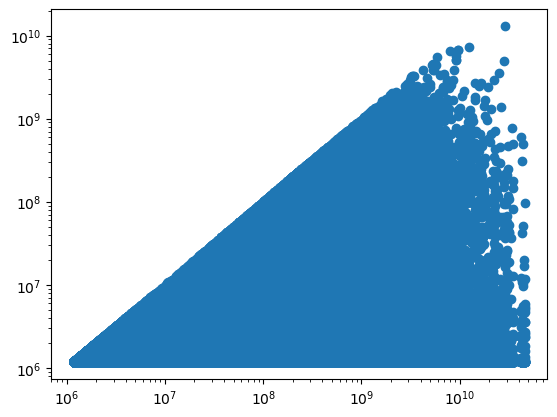

In [65]:
plt.loglog(M_1,M_2,'o')

# Defined Functions

### Parameter Generation

In [66]:
def random_pop(m1 = M_1, 
                m2 = M_2, dist = d_l, sample_size = 30000):

    # Generate random indices
    indices = random.sample(range(len(M_1)), sample_size)

    # Get elements from each array using the same indices
    M_1sample = np.array([m1[i] for i in indices])
    M_2sample = np.array([m2[i] for i in indices])
    d_lsample = np.array([dist[i] for i in indices])
    #SNR_sample = np.array([snr_tng300[i] for i in indices])
    
    
    result={
         'm1'  : M_1sample,
         'm2'  : M_2sample,
        'dist' : d_lsample,
    }
    return result 


In [67]:
def x_mean_plotter(x, y, xbins=10, color='red', marker='o', plt_type=True, xgmean=True, ygmean=True, plot=True, label=None):
    
    start = min(x)
    stop = max(x)
    
    if xgmean:
        values = np.logspace(np.log10(start), np.log10(stop), xbins)
    else:
        values = np.linspace(start, stop, xbins)
    x_mean = []
    y_mean = []

    for i in range(len(values)-1):
        mask_x = ((x > values[i]) & (x < values[i+1]) & (~np.isnan(y)))
        x_slice = values[i:i+2]
        if xgmean:
            x_mean.append(gmean(x_slice))
        else:
            x_mean.append(np.mean(x_slice))
        if ygmean:   
            y_mean.append(gmean(y[mask_x]))
        else:
            y_mean.append(np.mean(y[mask_x]))
        if plot:
            if plt_type:
                plt.plot(x_mean, y_mean, color=color, marker=marker)
            else:
                plt.scatter(x_mean, y_mean, color=color, marker=marker)

    return x_mean, y_mean


In [68]:
def draw_params(m1 = M_1, 
                m2 = M_2, dist = d_l,n=1): 
                
    arr_size=len(m1)*n
    
    
    m1new = list(chain.from_iterable(repeat(x, n) for x in m1))
    m2new = list(chain.from_iterable(repeat(x, n) for x in m2))
    distnew = list(chain.from_iterable(repeat(x, n) for x in dist))
    

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

### SNR Calculators

In [69]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
             num_elements = len(M_1),obs=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


In [70]:
def SNR_calc_opt(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(len(M_1), 0.0),
    chi2 = np.full(len(M_1), 0.0),
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
    f_ref = np.full(len(M_1), 0),
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
    lam = uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
    psi = uniform_dist(0.0, np.pi).rvs(len(M_1)),
    t_ref = np.full(len(M_1), 1e6),obs=1,
    num_elements=len(M_1),batch=100):

    #check if the length is same:
    assert len(m1) == len(m2) == len(chi1) == len(chi2) == len(dist) == len(phi_ref) == len(f_ref) == len(inc) == len(lam) == len(beta) == len(psi) == len(t_ref), "Array lengths are not equal"
    
    
    # Setup data holders
    Tobs = YRSID_SI / 12*obs   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    batch=batch
   
    for i in range((num_elements + batch - 1) // batch):
        start_i = i * batch
        end_i = min((i + 1) * batch, num_elements)
        
        AET_gen = tdi_wave_gen(
            m1[start_i:end_i],
            m2[start_i:end_i], 
            chi1[start_i:end_i],
            chi2[start_i:end_i],
            dist[start_i:end_i], 
            phi_ref[start_i:end_i],
            f_ref[start_i:end_i], 
            inc[start_i:end_i],
            lam[start_i:end_i],
            beta[start_i:end_i],
            psi[start_i:end_i],
            t_ref[start_i:end_i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
        for j in range(len(AET_gen)):
            data = DataResidualArray(AET_gen[j], f_arr=freqs)
            sens_mat = AET1SensitivityMatrix(data.f_arr)
            analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
            snr = analysis.snr()
            SNR_new.append(snr)

    return SNR_new

In [71]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


### New Function Testing

In [72]:
#wave_gen = PhenomHMAmpPhase()

#parameters from simulation
#m1 = 2e6
#m2 = 7e5
#dist = 15 * 1e9 * PC_SI

#fixed parameters
#chi1 = 0.5
#chi2 = 0.7
#phi_ref = 0.6
#_ref = 0.0
#t_ref = 1e6 # seconds
#length = 1024

#wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

In [73]:
# m1 = M_1
# m2 = M_2
# dist = d_l
# arr_size= len(m1)
# chi1 = np.full(arr_size, 0.5)
# chi2 = np.full(arr_size, 0.7)
# phi_ref = np.full(arr_size, 0.6)
# f_ref =  np.full(arr_size, 0.0)
# inc =  np.full(arr_size, np.pi / 8)
# lam =  np.full(arr_size, 0.5)
# beta = np.full(arr_size, -0.7)
# psi = np.full(arr_size, np.pi/4)
# t_ref = np.full(arr_size, 1e6) # seconds

# length = 1024

# # setup data holders
# Tobs = YRSID_SI/12   # 1 month
# dt = 10.0  # sec
# N = int(Tobs / dt)
# Tobs = N * dt

# freqs = np.fft.rfftfreq(N, dt)

# #print(freqs)

In [74]:
# tdi_wave_gen = BBHWaveformFD()
# wave_AET=[]
# for i in range(100):
#     AET_gen = tdi_wave_gen(
#         m1[i],
#         m2[i], 
#         chi1[i],
#         chi2[i],
#         dist[i],
#         phi_ref[i],
#         f_ref[i], 
#         inc[i],
#         lam[i],
#         beta[i],
#         psi[i],
#         t_ref[i],
#         length=1024, 
#         combine=False,  # TODO: check this
#         direct=False,
#         fill=True,
#         squeeze=True,
#         freqs=freqs
#     )[0]
#     wave_AET.append(AET_gen)
#     #print(AET_gen)

#     #print(AET.shape)
# wave_AET=np.array(wave_AET)
# #print(wave_AET.shape) """
# """ snr_tng50=[]
# for i in range(100):
#     data = DataResidualArray(wave_AET[i], f_arr=freqs)
#     sens_mat = AET1SensitivityMatrix(data.f_arr)
#     analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#     snr=analysis.snr()
#     snr_tng50.append(snr)
#     #print(snr_tng50) 

In [75]:
# m1 = M_1[0:100]
# m2 = M_2[0:100]
# dist = d_l[0:100]
# arr_size= len(m1)
# chi1 = np.full(arr_size, 0.5)
# chi2 = np.full(arr_size, 0.7)
# phi_ref = np.full(arr_size, 0.6)
# f_ref =  np.full(arr_size, 0.0)
# inc =  np.full(arr_size, np.pi / 8)
# lam =  np.full(arr_size, 0.5)
# beta = np.full(arr_size, -0.7)
# psi = np.full(arr_size, np.pi/4)
# t_ref = np.full(arr_size, 1e6) # seconds

# length = 1024

# # setup data holders
# Tobs = YRSID_SI/12   # 1 month
# dt = 10.0  # sec
# N = int(Tobs / dt)
# Tobs = N * dt
# SNR_new=[]
# freqs = np.fft.rfftfreq(N, dt)

# AET_gen = tdi_wave_gen(
#             m1,
#             m2, 
#             chi1,
#             chi2,
#             dist, 
#             phi_ref,
#             f_ref, 
#             inc,
#             lam,
#             beta,
#             psi,
#             t_ref,
#             length=1024, 
#             combine=False,  # TODO: check this
#             direct=False,
#             fill=True,
#             squeeze=True,
#             freqs=freqs
#         )
# for j in range(len(AET_gen)):
#     data = DataResidualArray(AET_gen[j], f_arr=freqs)
#     sens_mat = AET1SensitivityMatrix(data.f_arr)
#     analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#     snr = analysis.snr()
#     SNR_new.append(snr) 

# Analysis
 

Loading Calculations

In [76]:

snr_tng300=np.load('snr_tng300.npy')
snr_tng300_old=np.load('snr_tng300_old.npy')

In [77]:
reduced_M_1=np.load('M1_mass_fact.npy')
reduced_M_2=np.load('M2_mass_fact.npy')

##### Plots


Text(0, 0.5, 'SNR')

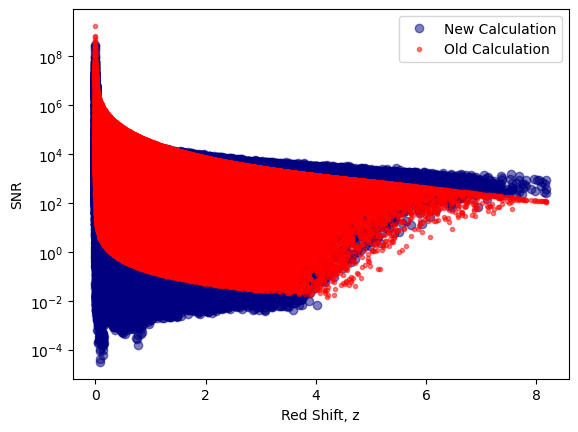

In [78]:
plt.plot(z,snr_tng300,'o',alpha=.5,c='navy',label='New Calculation')
plt.plot(z,snr_tng300_old,'.',alpha=.5,c='red',label='Old Calculation')
plt.yscale('log')
plt.legend()
plt.xlabel('Red Shift, z')
plt.ylabel('SNR')

Text(0, 0.5, 'SNR')

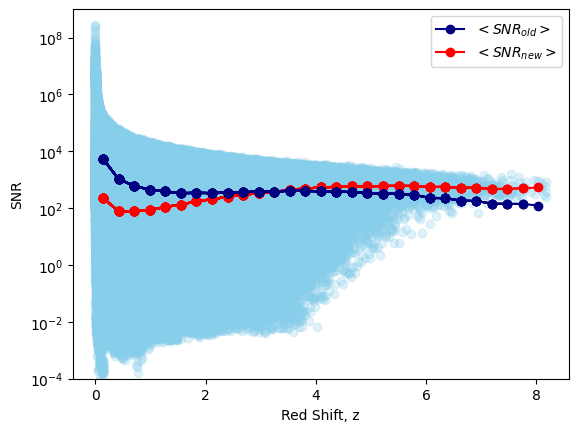

In [79]:
plt.plot(z,snr_tng300,'o',alpha=.25,c='skyblue')
#plt.plot(z,snr_tng300_old,'.',alpha=.5,c='red',label='Old Calculation')
avg_x1, avg_y1=x_mean_plotter(z, snr_tng300 ,xgmean=False,xbins=30)
avg_x2, avg_y2=x_mean_plotter(z, snr_tng300_old,xgmean=False,xbins=30,color='Navy')

plt.plot(1,10**20,label='$<SNR_{old}>$', marker='o',c='navy')
plt.plot(1,10**20,label='$<SNR_{new}>$', marker='o',c='r')


plt.ylim(1e-4,1e9)

plt.yscale('log')
plt.legend()
plt.xlabel('Red Shift, z')
plt.ylabel('SNR')

In [80]:
# fn = np.logspace(-6, -1, 10000)
# Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
# plt.loglog(fn, Sn_char_strain)
# plt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label='A')
# plt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label='E')
# plt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label='T')
# plt.legend()

In [81]:
# snr_tng50=[]
# for i in range(700):
#     data = DataResidualArray(wave_AET[i], f_arr=freqs)
#     sens_mat = AET1SensitivityMatrix(data.f_arr)
#     analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#     snr=analysis.snr()
#     snr_tng50.append(snr)
#     #print(snr_tng50)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


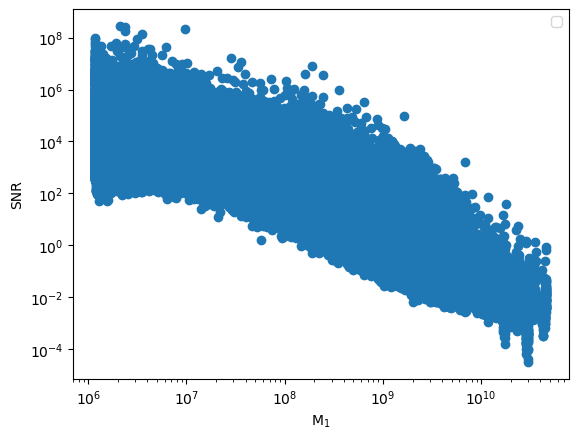

In [82]:
plt.loglog(M_1,snr_tng300,'o')
#plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

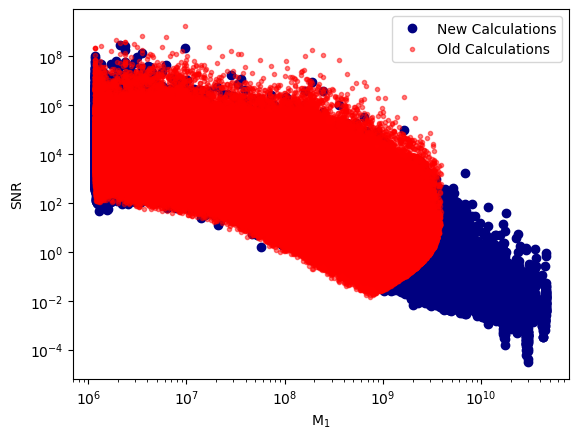

In [83]:
plt.loglog(M_1,snr_tng300,'o',label='New Calculations',c='navy')
plt.loglog(M_1,snr_tng300_old,'.',label='Old Calculations', c='red',alpha=.5)
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()
plt.savefig

Mask

In [84]:
snr_tng300=np.array(snr_tng300)
mask=(snr_tng300>1)

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


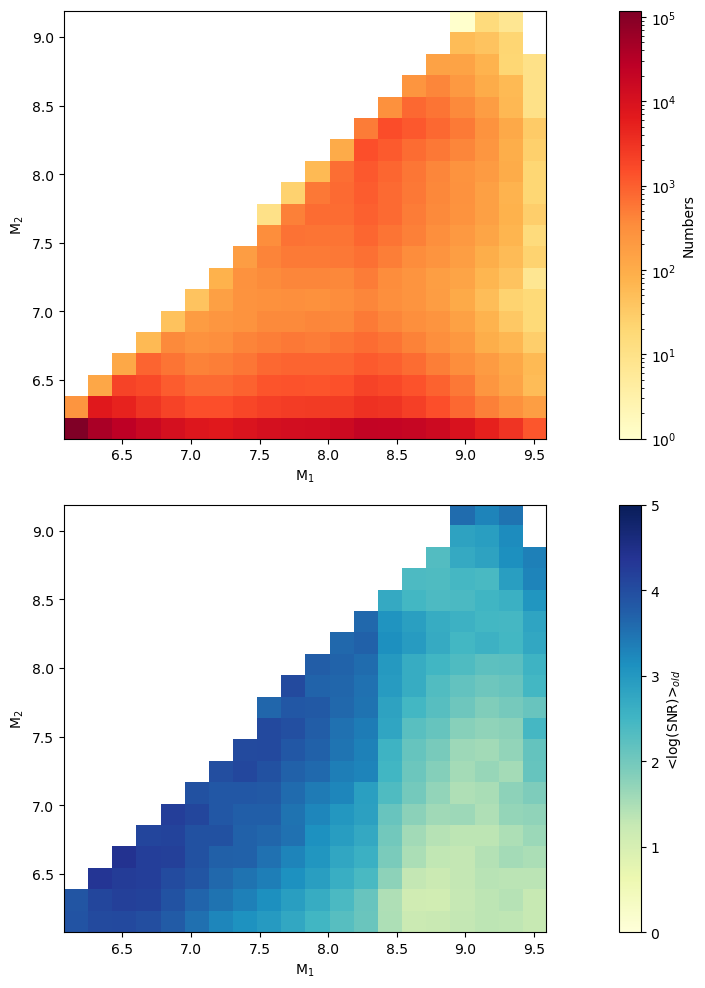

In [85]:
avg_hist(np.log10(M_1[mask]), np.log10(M_2[mask]),snr_tng300_old[mask],labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{old}$', logweight=True,vmin=0,vmax=5)
#plt.savefig('avg_hist_m1m2snr_o.png', dpi=300)

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


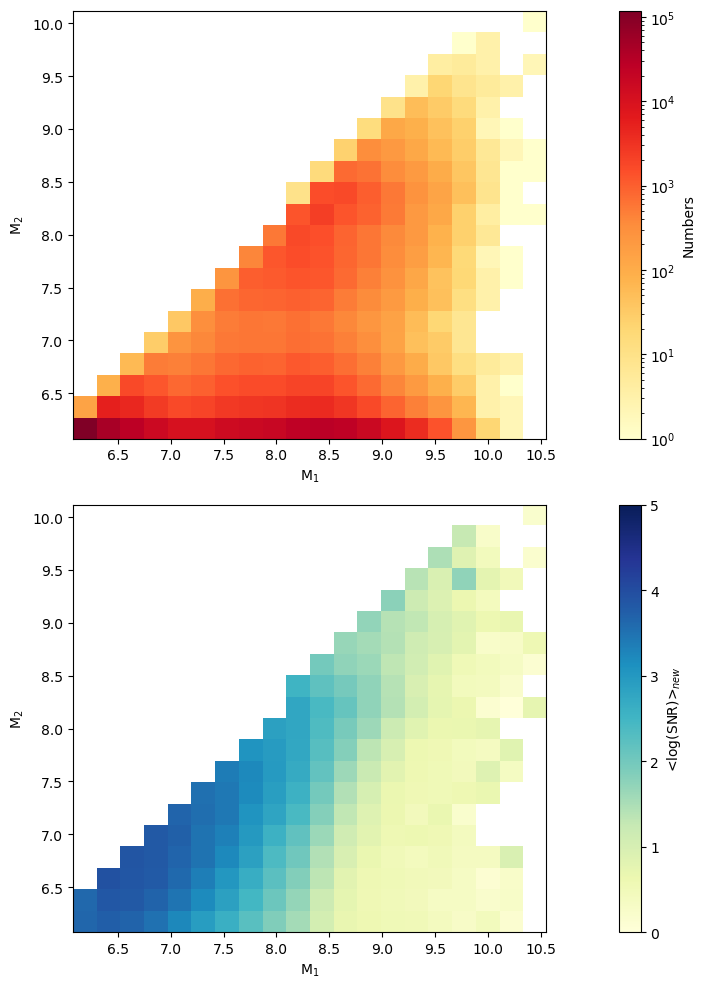

In [86]:
avg_hist(np.log10(M_1[mask]), np.log10(M_2[mask]),snr_tng300[mask],labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{new}$', logweight=True,vmin=0,vmax=5)
#plt.savefig('avg_hist_m1m2snr_n.png', dpi=300)

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


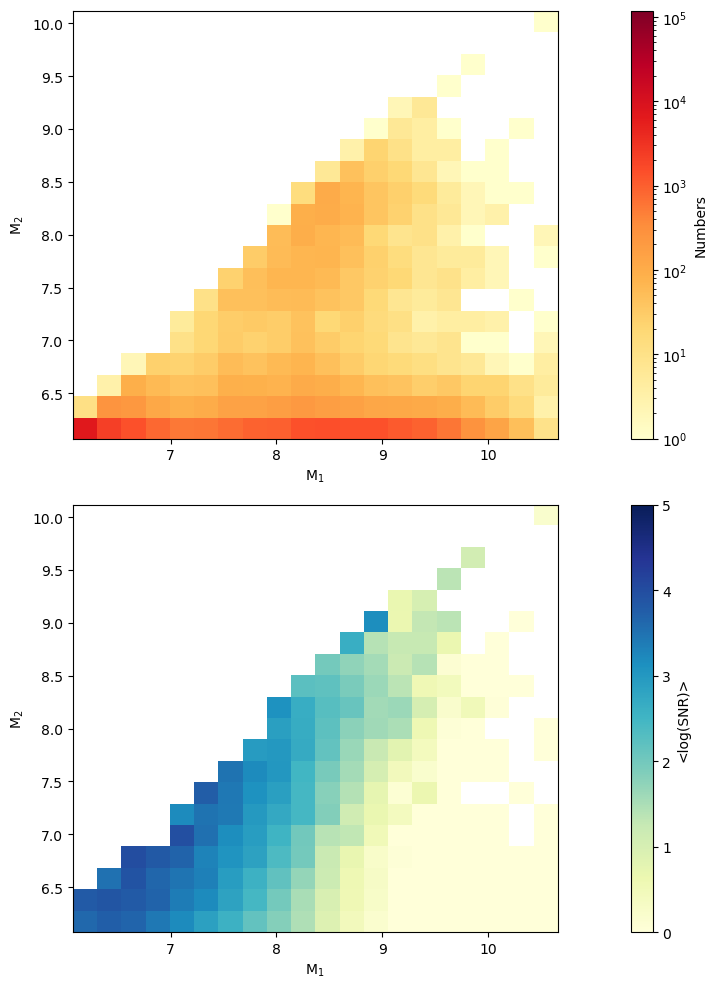

In [87]:
sample_size = 30000
# Generate random indices
indices = random.sample(range(len(M_1)), sample_size)

# Get elements from each array using the same indices
M_1sample = np.array([M_1[i] for i in indices])
M_2sample = np.array([M_2[i] for i in indices])
SNR_sample = np.array([snr_tng300[i] for i in indices])
reduced_M_1sample=np.array([M_1[i] for i in indices])
reduced_M_2sample=np.array([M_2[i] for i in indices])
d_lsample = np.array([d_l[i] for i in indices])
avg_hist(np.log10(M_1sample),np.log10(M_2sample),SNR_sample,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [88]:
# sample_params=draw_params(m1=M_1sample, m2=M_2sample,dist=d_lsample)
# sample_reduced_params=draw_params(m1=reduced_M_1sample, m2=reduced_M_2sample,dist=d_lsample)

In [89]:
# snr_sample=SNR_calc(**sample_params)
# snr_reduced_sample=SNR_calc(**sample_reduced_params)

In [90]:
# np.save('snr_sample.npy', snr_sample)
# np.save('snr_reduced_sample.npy', snr_reduced_sample)

In [92]:
# avg_hist(np.log10(M_1sample),np.log10(M_2sample),np.array(snr_reduced_sample)/np.array(snr_sample),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True)#,vmin=0,vmax=5)

In [93]:
rand_pop_2=random_pop(sample_size=30000)
rand_draw_2=draw_params(**rand_pop_2)

In [94]:
rand_pop_2_M1=np.array(rand_draw_2['m1'])
rand_pop_2_M2=np.array(rand_draw_2['m2'])

In [95]:
snr_random_pop2_obs_1=SNR_calc(**rand_draw_2)

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


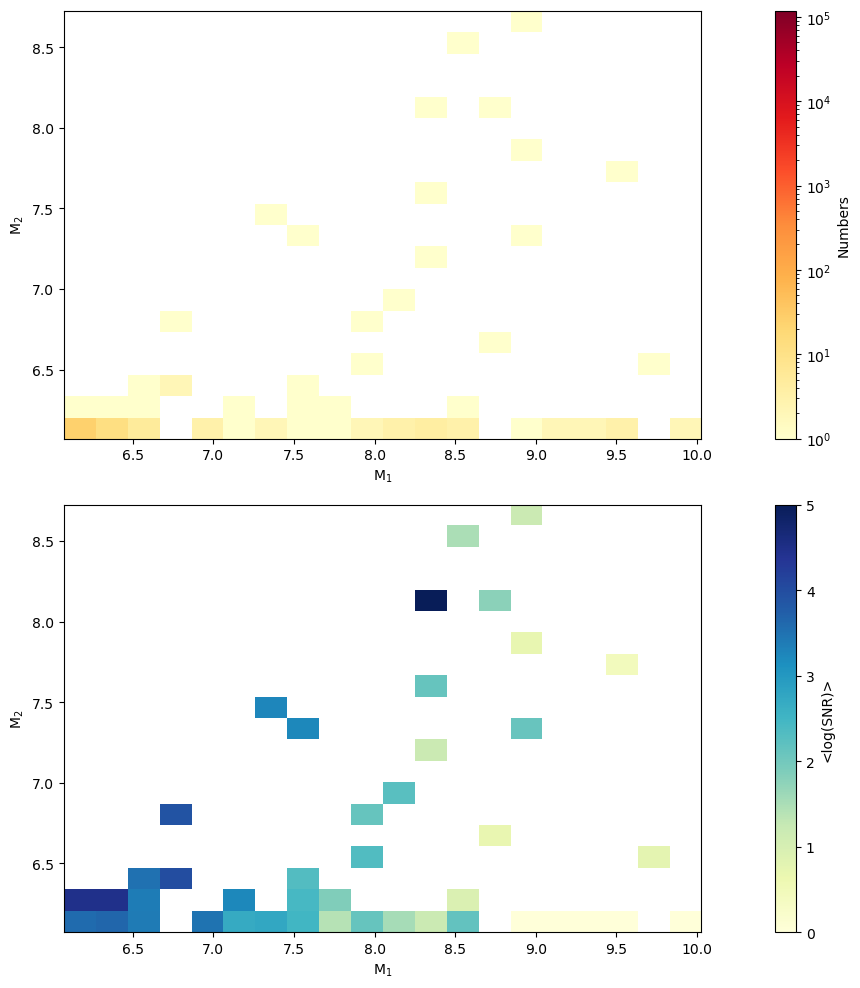

In [ ]:

avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_1),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# snr_test_opt=SNR_calc_opt(**rand_draw_1)

In [ ]:
snr_random_pop2_obs_3=SNR_calc(**rand_draw_2,obs=3)

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


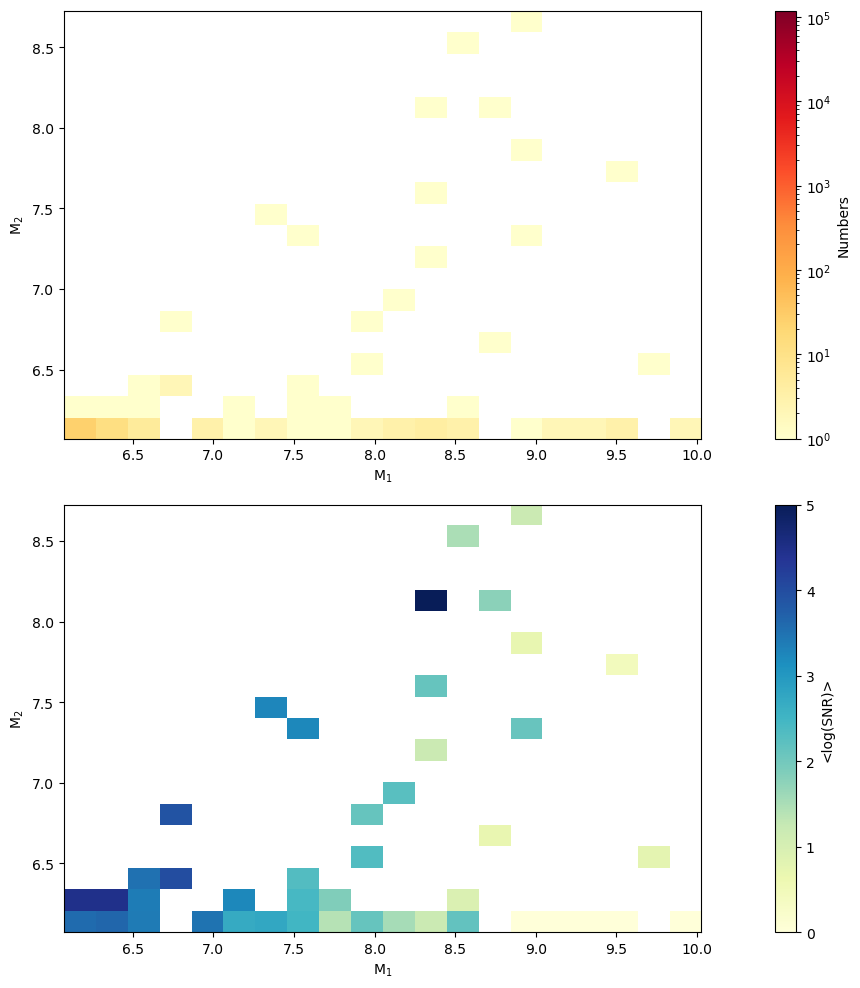

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_3),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
snr_random_pop2_obs_6=SNR_calc(**rand_draw_2,obs=6)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


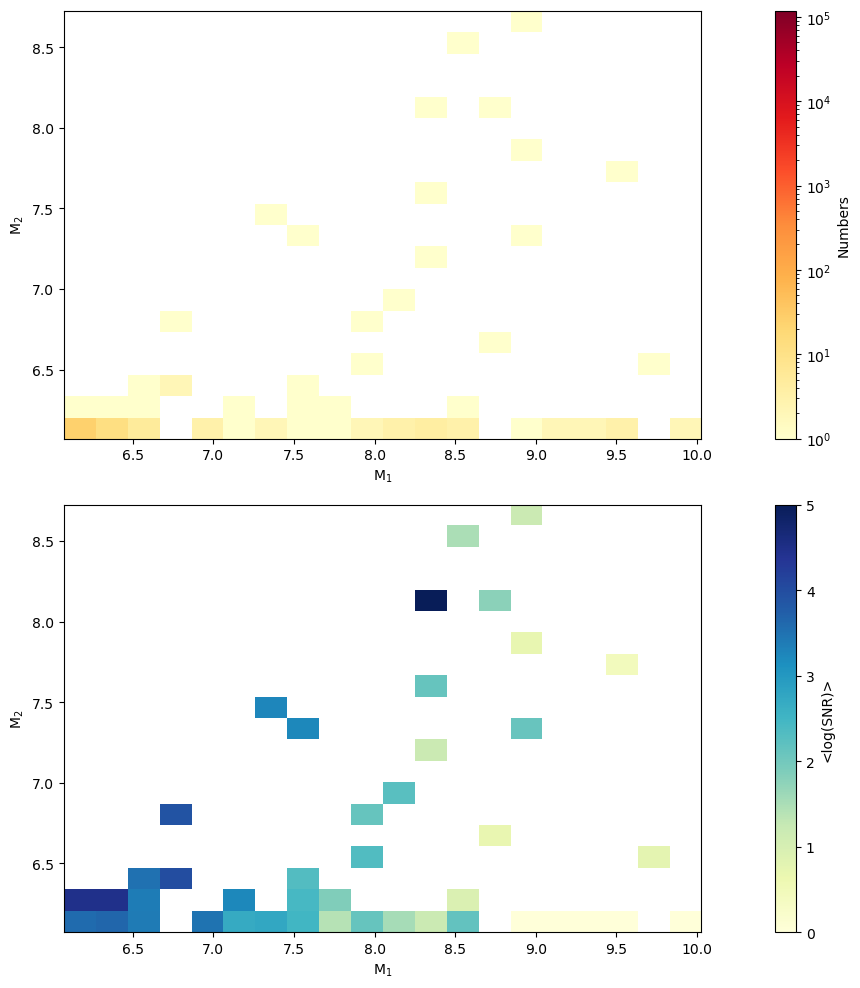

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_6),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
snr_random_pop2_obs_12=SNR_calc(**rand_draw_2,obs=12)


/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

/tmp/ipykernel_2214/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


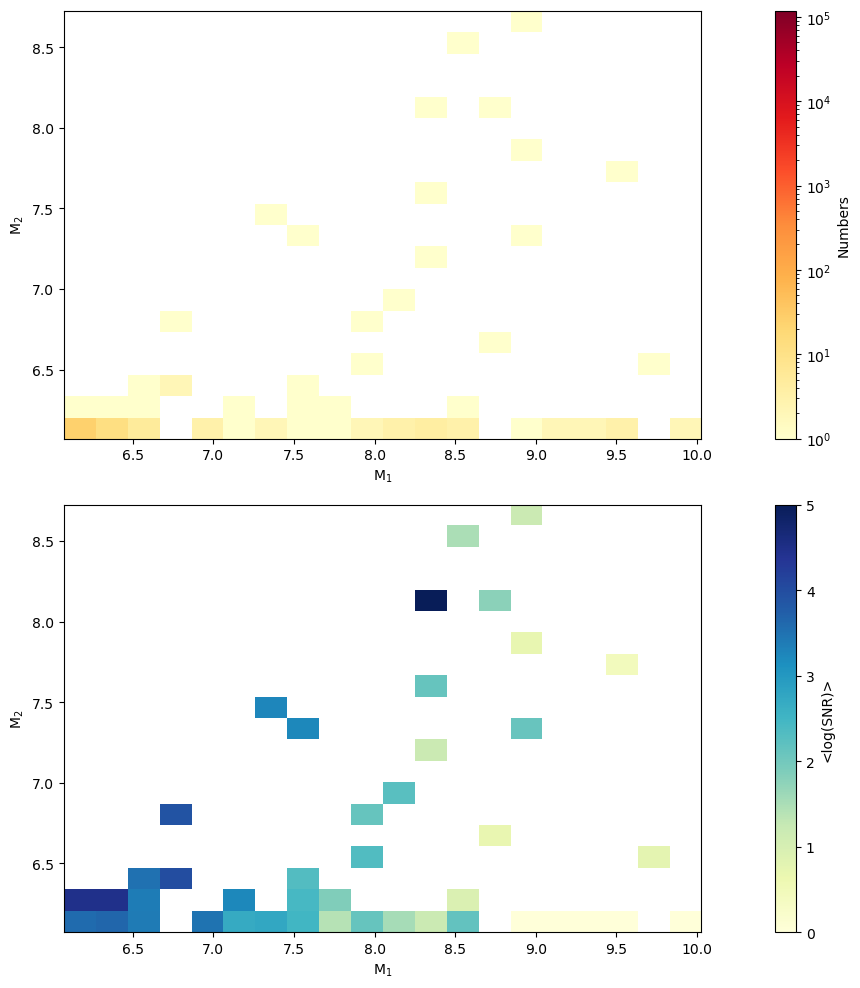

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_12),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
np.array('')

In [79]:
# np.save('snr_random_pop1_obs_1.npy',snr_random_pop1_obs_1)
# np.save('snr_random_pop1_obs_3.npy',snr_random_pop1_obs_3)
# np.save('snr_random_pop1_obs_6.npy',snr_random_pop1_obs_6)

In [61]:
# snr_random_pop1_obs_1=np.load('snr_random_pop1_obs_1.npy')
# snr_random_pop1_obs_3=np.load('snr_random_pop1_obs_3.npy')
# snr_random_pop1_obs_6=np.load('snr_random_pop1_obs_6.npy')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


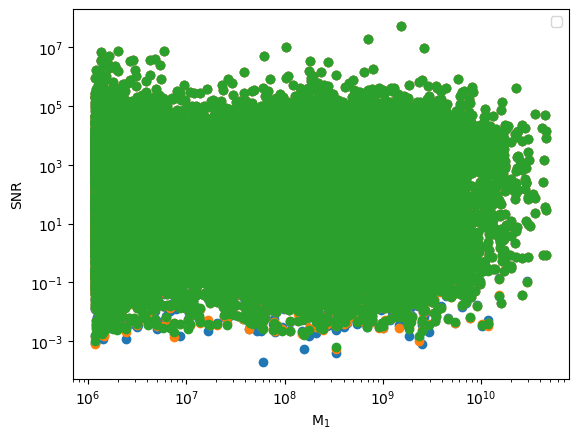

In [62]:
# rand_pop_1_M1=rand_draw_1['m1']
# rand_pop_1_M2=rand_draw_1['m2']

# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_1,'o')
# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_3,'o')
# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_6,'o')
# #plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
# plt.xlabel('M$_1$')
# plt.ylabel('SNR')
# plt.legend()

/tmp/ipykernel_1690/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


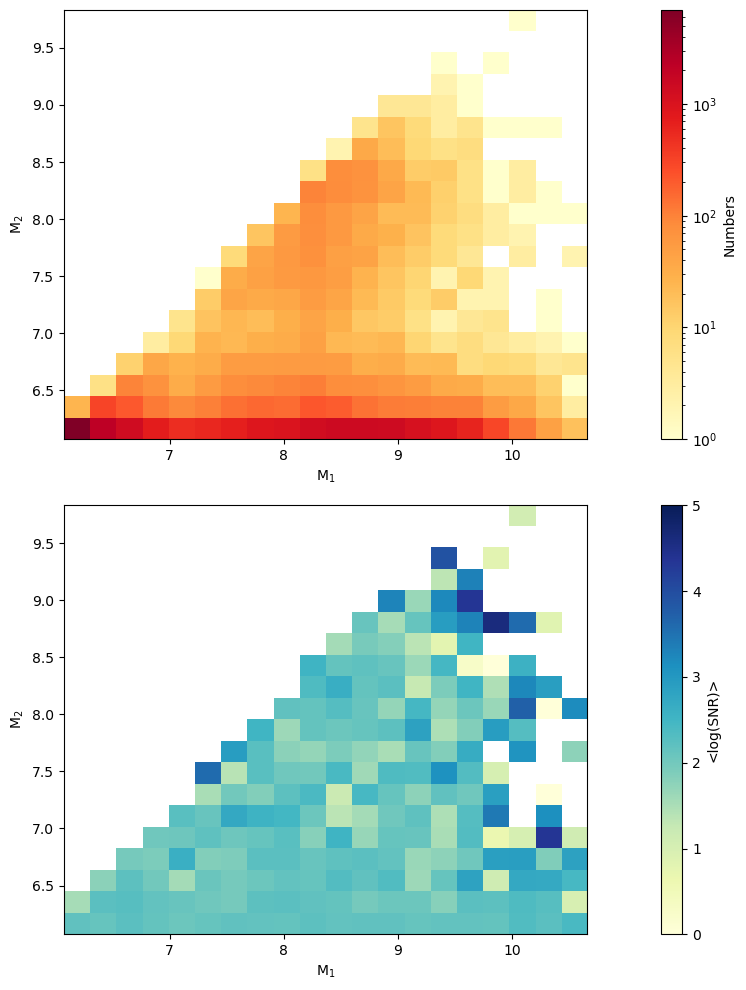

In [86]:
avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_1,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

/tmp/ipykernel_1690/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


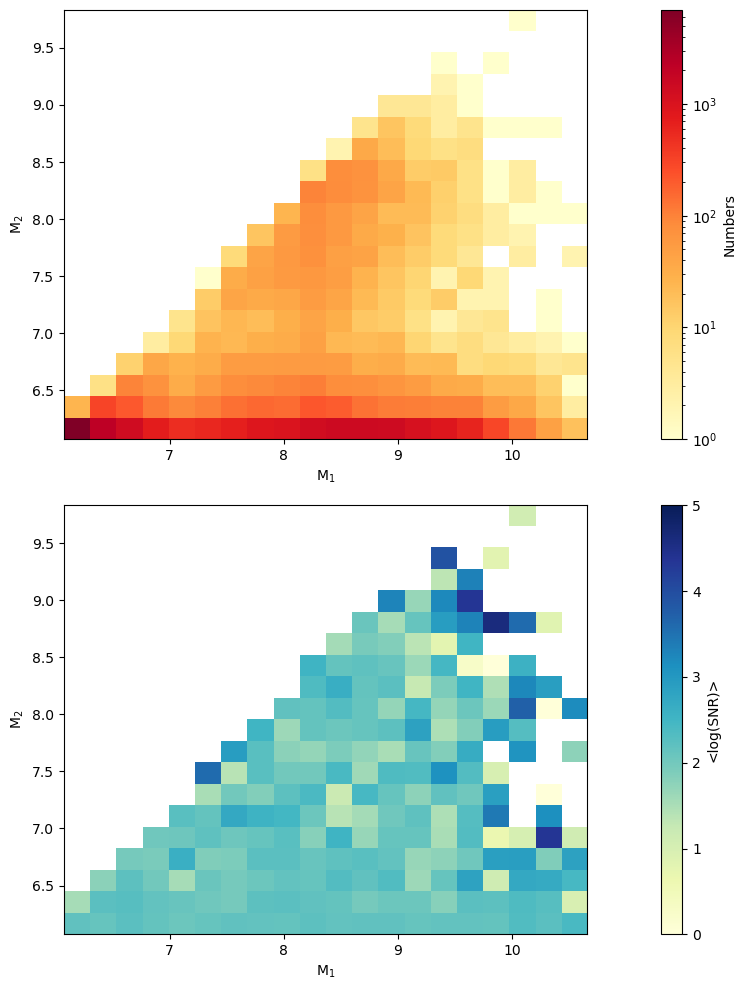

In [87]:
avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_3,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

/tmp/ipykernel_1690/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


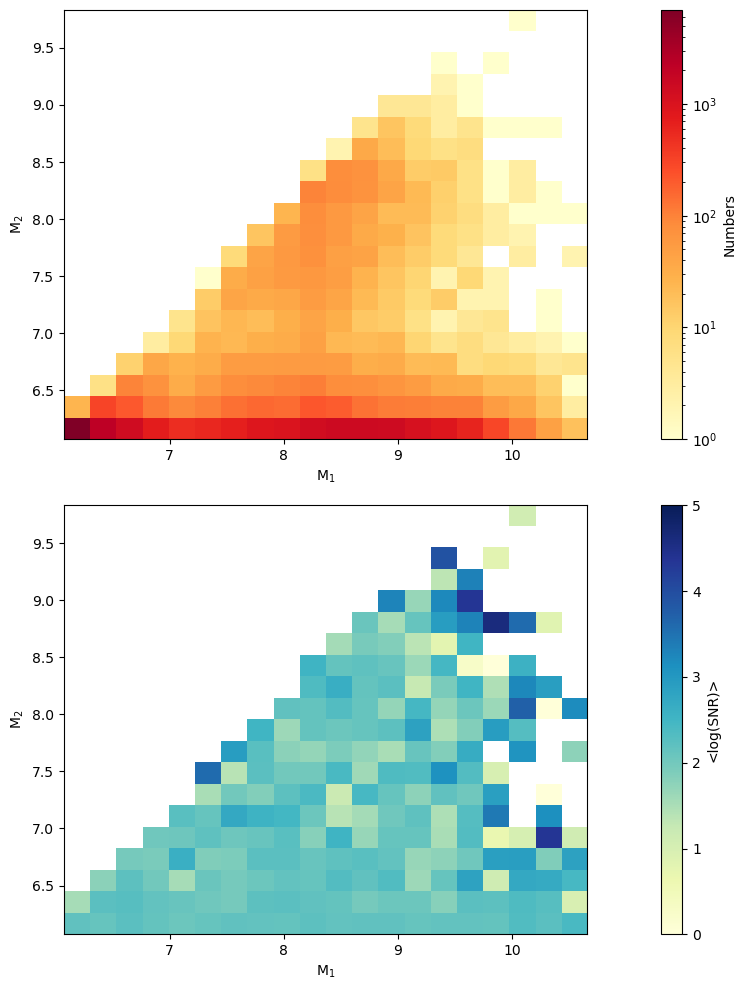

In [88]:
avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_6,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

## Small Mass

In [66]:
random_pop(m1=reduced_M_1,m2=reduced_M_2)

{'m1': array([108805.59823384, 155975.04267024, 128056.06188654, ...,
        107449.61307348, 133234.35128834, 117303.1323887 ]),
 'm2': array([5.89775597e+08, 5.60631828e+08, 1.33858138e+08, ...,
        2.70676106e+07, 2.25228808e+09, 3.03811647e+07]),
 'dist': array([1.35144458e+26, 1.76464373e+26, 2.87118328e+26, ...,
        4.44303874e+26, 1.73679688e+26, 1.37888018e+26])}

In [77]:
reduced_random_pop1=draw_params(**random_pop(m1=reduced_M_1,m2=reduced_M_2))

In [85]:
snr_reduced=SNR_calc(**reduced_random_pop1)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

In [80]:
rand_reduced_M_1=reduced_random_pop1['m1']
rand_reduced_M_2=reduced_random_pop1['m2']

/tmp/ipykernel_1690/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


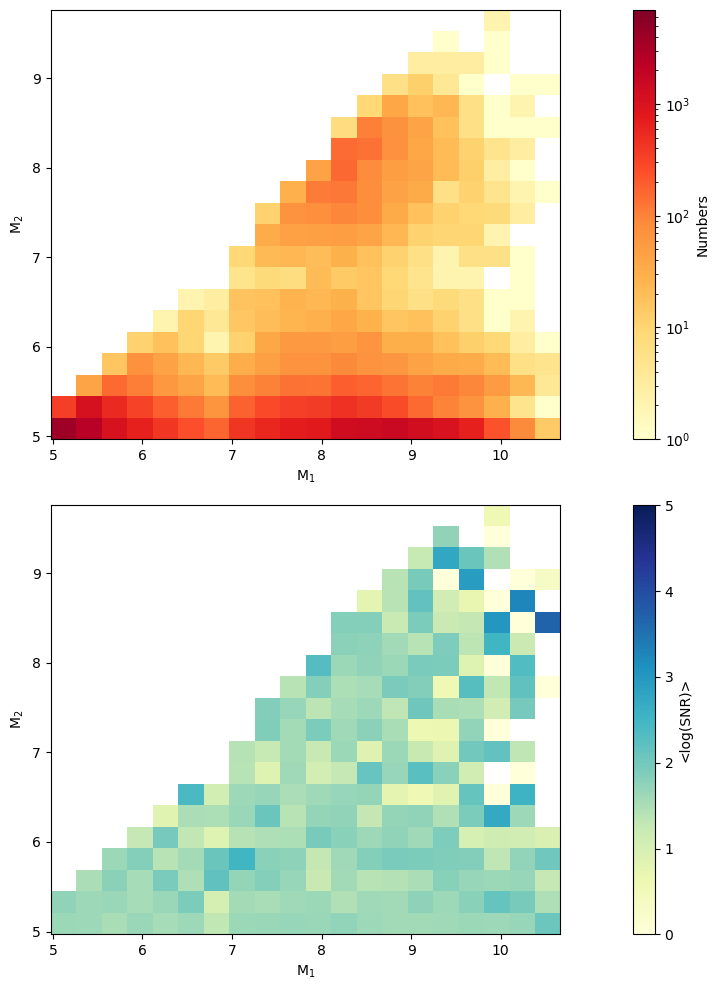

In [84]:
avg_hist(np.log10(rand_reduced_M_1),np.log10(rand_reduced_M_2),np.array(snr_reduced),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)